<a href="https://colab.research.google.com/github/harimshin/data-science-portfolio/blob/main/Causal_Inference_for_Job_Coprs_Program_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Data Import and Preparation**


In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/harimshin/private_data/refs/heads/main/JCdata6933.csv'
df = pd.read_csv(url, index_col = False)
print(df.shape)

(9799, 22)


Categorical indicators for race are created to allow inclusion in statistical models. Specifically, the numeric race variable is first mapped into human-readable categories, and then converted into binary (one-hot encoded) dummy variables. The “other” category is dropped to serve as the reference group, avoiding multicollinearity. Finally, the resulting dummy variables are merged back into the main dataset for further analysis.

In [2]:
race_map = {0:"other", 1:"white", 2:"black", 3:"hispanic"}
df["race_str"] = df["race"].map(race_map)
race_dummies = pd.get_dummies(df["race_str"]).astype(int)
race_dummies = race_dummies.drop(columns = "other")

df = pd.concat([df, race_dummies], axis=1)
print(df.head())

   Unnamed: 0     id  race  hs_ged        age  hgcb  mar  hhead    baseweek  \
0           1  60037     1       1  18.129999     8    0      0  318.500000   
1           2  75019     1       0  16.180000     8    0      0  500.000000   
2           3  77017     2       0  18.309999    10    0      0  109.010002   
3           4  82015     1       0  17.030001    10    0      0  110.000000   
4           5  92076     3       1  21.480000    12    0      0  172.500000   

   guilt  ...  msa  english        age2  emp  unemp  child  race_str  black  \
0      0  ...    1        1  328.696869    0      1      0     white      0   
1      0  ...    0        1  261.792419    0      1      0     white      0   
2      0  ...    0        1  335.256073    0      1      0     black      1   
3      0  ...    1        1  290.020935    0      1      0     white      0   
4      0  ...    1        0  461.390381    1      0      0  hispanic      0   

   hispanic  white  
0         0      1  
1       

Key variable names and covariate groups were defined in advance to improve code readability, consistency, and reusability when building causal inference functions. Continuous and binary covariates were stored separately and then combined into a unified covariate list for downstream modeling and estimation procedures.

In [3]:
treat_col = "everjc"
outcome_col = "earnq16"

cont_covs = ["age", "hgcb", "baseweek", "age2"]
bin_covs = ["hs_ged", "mar", "hhead", "guilt", "female", "pmsa", "msa",
            "english", "emp", "unemp", "child", "white", "black", "hispanic"]
covariates = cont_covs + bin_covs

Basic data validation and preprocessing were performed prior to analysis. First, the treatment indicator was verified to be binary (0/1), consistent with the requirements of the causal inference methods used in this study. Observations with missing values in the treatment, outcome, or covariate variables were removed, and the treatment indicator was converted to an integer type to ensure consistency in downstream modeling procedures.

In [4]:
# basic checks
assert set(df[treat_col].unique()).\
    issubset({0, 1}),\
   "Treatment must be binary (0/1)"
df = df[[treat_col, outcome_col] + covariates].dropna()
df[treat_col] = df[treat_col].astype(int)

In [5]:
# check dimension of data and treatment rate
print("Shape of data:", df.shape)
print("Treatment rate:", df[treat_col].mean().round(4))

Shape of data: (9799, 20)
Treatment rate: 0.4501


**2. Exploratory Data Analysis (EDA)**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def exploratory_data_analysis(
    df,
    treat_col,
    outcome_col,
    cont_covs,
    bin_covs
):

    # Basic dataset summary

    print("=" * 60)
    print("Dataset Summary")
    print("=" * 60)

    print(f"Number of observations: {len(df)}")
    print(f"Treatment proportion:")
    print(df[treat_col].value_counts(normalize=True).round(3))

    print("\nMissing values:")
    print(df.isnull().sum())


    # Outcome summary by treatment

    print("\n" + "=" * 60)
    print("Outcome Summary by Treatment Group")
    print("=" * 60)

    outcome_summary = (
        df.groupby(treat_col)[outcome_col]
        .agg(["mean", "std", "median", "min", "max", "count"])
        .round(4)
    )

    print(outcome_summary)


    # Continuous covariate summary

    print("\n" + "=" * 60)
    print("Continuous Covariate Summary")
    print("=" * 60)

    cont_summary = (
        df.groupby(treat_col)[cont_covs]
        .mean()
        .T
        .round(4)
    )

    cont_summary.columns = ["treated_mean", "control_mean"]

    print(cont_summary)


    # Binary covariate summary

    print("\n" + "=" * 60)
    print("Binary Covariate Summary")
    print("=" * 60)

    bin_summary = (
        df.groupby(treat_col)[bin_covs]
        .mean()
        .T
        .round(4)
    )

    bin_summary.columns = ["treated_pct", "control_pct"]

    print(bin_summary)


    # Outcome distribution plot

    plt.figure(figsize=(4, 3))

    plt.hist(
        df[df[treat_col] == 1][outcome_col],
        bins=30,
        alpha=0.6,
        label="treated"
    )

    plt.hist(
        df[df[treat_col] == 0][outcome_col],
        bins=30,
        alpha=0.6,
        label="control"
    )

    plt.xlabel(outcome_col)
    plt.ylabel("Frequency")
    plt.title("Outcome Distribution by Treatment Group")
    plt.legend()
    plt.grid(True)
    plt.show()


    # Continuous covariate plots

    for cov in cont_covs:

        plt.figure(figsize=(4, 3))

        plt.hist(
            df[df[treat_col] == 1][cov],
            bins=30,
            alpha=0.6,
            label="treated"
        )

        plt.hist(
            df[df[treat_col] == 0][cov],
            bins=30,
            alpha=0.6,
            label="control"
        )

        plt.xlabel(cov)
        plt.ylabel("Frequency")
        plt.title(f"{cov} Distribution by Treatment Group")
        plt.legend()
        plt.grid(True)
        plt.show()

    # return {
    #     "outcome_summary": outcome_summary,
    #     "continuous_summary": cont_summary,
    #     "binary_summary": bin_summary
    # }

Dataset Summary
Number of observations: 9799
Treatment proportion:
everjc
0    0.55
1    0.45
Name: proportion, dtype: float64

Missing values:
everjc      0
earnq16     0
age         0
hgcb        0
baseweek    0
age2        0
hs_ged      0
mar         0
hhead       0
guilt       0
female      0
pmsa        0
msa         0
english     0
emp         0
unemp       0
child       0
white       0
black       0
hispanic    0
dtype: int64

Outcome Summary by Treatment Group
            mean       std  median  min     max  count
everjc                                                
0       203.9348  199.9268  181.02  0.0  1000.0   5388
1       214.5868  206.4742  197.94  0.0  1000.0   4411

Continuous Covariate Summary
          treated_mean  control_mean
age            18.8952       18.7578
hgcb           10.1412       10.0268
baseweek      111.4578      106.4929
age2          361.6702      356.5292

Binary Covariate Summary
          treated_pct  control_pct
hs_ged         0.2507       0.2

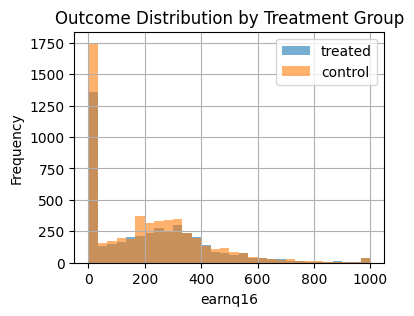

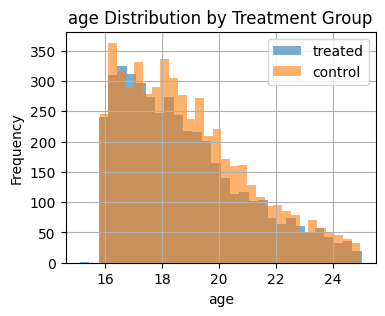

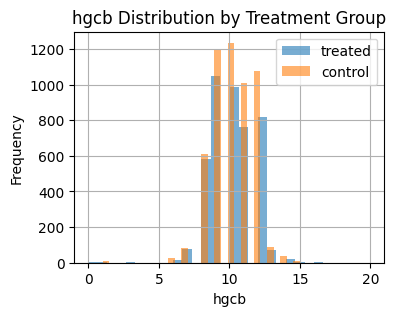

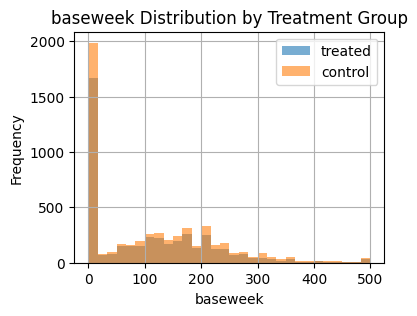

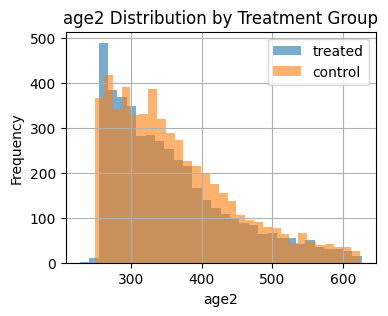

In [7]:
exploratory_data_analysis(
    df,
    treat_col,
    outcome_col,
    cont_covs,
    bin_covs
)

The distribution of `earnq16` is highly right-skewed for both treated and control groups, with a large concentration of observations at low earnings levels and a long upper tail. The two groups exhibit substantial overlap in their outcome distributions, suggesting broadly similar earnings patterns prior to formal causal effect estimation.
Visual inspection of the continuous covariate distributions indicates substantial overlap between treated and control groups across most variables, suggesting reasonable baseline comparability on observed characteristics.
`age` and `age2` display similar right-skewed distributions across groups, although treated individuals appear slightly younger on average. Educational attainment (`hgcb`) is also broadly similar, with treated individuals showing a modest shift toward higher education levels. The distribution of baseline earnings (`baseweek`) is highly skewed with a large mass at zero for both groups, indicating a substantial proportion of individuals with no baseline earning. While visual differences are present for some covariates, none appear severe enough to suggest a lack of common support.

### Identification Assumption: Conditional Ignorability

All observational estimators rest on the conditional independence assumption
(CIA): conditional on observed covariates X, potential outcomes are
independent of treatment assignment, (Y(0), Y(1)) ⊥ T | X. Once we
condition on X, we assume no remaining systematic difference between
enrollees and non-enrollees that also affects earnings.

For Job Corps, this is plausible given the dataset's coverage of the primary
selection dimensions — baseline earnings, age, education, race, and family
structure — which jointly determine both program eligibility and labor market
prospects. The main residual threat is selection on unobservables,
particularly motivation: voluntary enrollees may be more job-search oriented
in ways not captured by the covariates, likely biasing estimates upward.
That our observational estimates ($14–16) align closely with the
experimental benchmark from the National JTPA Study provides some
reassurance that this bias, while not eliminable, is not severe.

**2. Treatment Effect Estimation Using Difference-in-Differences (DID)**

Difference-in-differences (DID) was used as a baseline causal inference approach to estimate the average treatment effect by comparing changes in outcomes between treated and control groups over time. DID provides an interpretable benchmark estimate while accounting for time-invariant unobserved differences between groups under the parallel trends assumption.
Because individual-level pre- and post-treatment outcomes are available, the estimate here uses a first-difference (change score) specification. This controls for time-invariant individual heterogeneity but rests on the assumption that, absent treatment, individuals' earnings trajectories would have evolved similarly across groups.

In [8]:
# create a column for outcome differences
df["delta"] = df[outcome_col] - df["baseweek"]
diff_col = "delta"

In [9]:
import statsmodels.api as sm

def did_att(df, treat_col, diff_col):

    X = sm.add_constant(df[treat_col])
    Y = df[diff_col]

    did_reg_model = sm.OLS(Y, X).fit(cov_type='HC1')

    estimate = did_reg_model.params[treat_col]
    se = did_reg_model.bse[treat_col]
    tstat = did_reg_model.tvalues[treat_col]
    pval = (did_reg_model.pvalues[treat_col]
            if did_reg_model.pvalues[treat_col] > 1e-4
            else "<0.0001")

    did_att_summary = pd.Series({
        "method": "DID",
        "effect": "ATT",
        "estimate": round(estimate, 4),
        "se": round(se, 4),
        "t-stat": round(tstat, 4),
        "p-value": round(pval, 4)
    })

    return did_att_summary

In [10]:
did_att_summary = did_att(df, treat_col, diff_col)
print(did_att_summary)

method          DID
effect          ATT
estimate    15.6169
se           4.2938
t-stat        3.637
p-value      0.0003
dtype: object


**3. Propensity Score Estimation and Trimming**

*3-1. Propensity Score Estimation Using Gradient Boosting*

The propensity score is defined as the probability of treatment assignment conditional on observed covariates. In this analysis, propensity scores were estimated using observed demographic and socioeconomic covariates to summarize treatment assignment probabilities into a single metric. Estimating propensity scores helps reduce observable differences between treated and control groups and supports causal effect estimation under the conditional independence assumption.

In [11]:
import numpy as np
from sklearn.model_selection import KFold
from lightgbm import LGBMClassifier

def pscore_lgbm(df, n_splits=5, random_state=42):\

    X = df[covariates]
    T = df[treat_col]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    ps = np.zeros(len(X))

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        T_train = T.iloc[train_idx]

        gb_model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            min_child_samples=20,
            verbosity=-1
        )

        gb_model.fit(X_train, T_train)

        ps[test_idx] = gb_model.predict_proba(X_test)[:, 1]

    return ps

In [12]:
df['pscore'] = pscore_lgbm(df)
pscore_col = 'pscore'
ps = df[pscore_col]

In [13]:
print(df[pscore_col].round(4).head(10).to_string(index=False))

0.3743
0.4597
0.5438
0.5431
0.3823
0.5566
0.4019
0.1864
0.4263
0.3927


*3-2. Assessment of Propensity Score Balance Between Groups*

The propensity score distributions of treated and control groups are compared using histograms to assess overlap and common support between the groups. Similar distributions indicate that treated and control individuals have comparable probabilities of treatment assignment, which supports the validity of propensity score–based causal inference methods.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pscore_overlap(df, treat_col, pscore_col, bins=30):

    ps_treated = df[df[treat_col] == 1][pscore_col]
    ps_control = df[df[treat_col] == 0][pscore_col]

    sns.set(style="whitegrid")

    plt.figure(figsize=(6, 4))

    sns.histplot(
        ps_treated,
        bins=bins,
        color='teal',
        alpha=0.6,
        stat='count',
        label='Treated',
        kde=False,
        edgecolor=None
    )

    sns.histplot(
        ps_control,
        bins=bins,
        fill=False,
        stat='count',
        label='Control',
        kde=False,
        edgecolor='blue'
    )

    plt.xlabel('Propensity Score')
    plt.ylabel('Count')
    plt.title('Overlap Check')
    plt.legend()

    plt.tight_layout()
    plt.show()

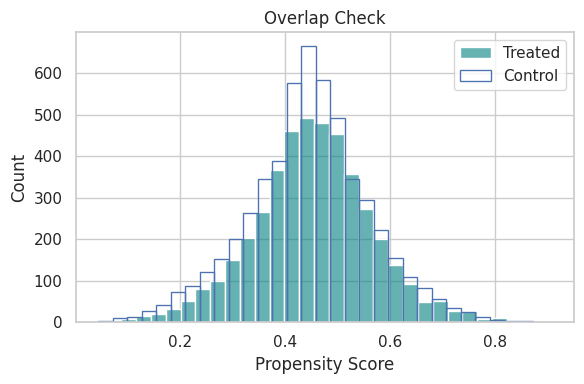

In [15]:
plot_pscore_overlap(df, treat_col, pscore_col)

The histogram shows substantial overlap in propensity score distributions between treated and control groups, particularly in the central range (approximately 0.3–0.6). This indicates that the common support assumption is largely satisfied, with both groups well represented across most of the propensity score range. While there are slightly fewer observations at the extremes, no severe lack of overlap is evident, suggesting that the sample is suitable for reliable causal estimation without significant extrapolation.

*3-3. Common Support Trimming*

Common support trimming was performed to improve comparability between treated and control groups by removing observations with non-overlapping propensity score ranges, restricting the analysis to regions where both groups are sufficiently represented. This reduces reliance on extrapolation and improves the stability and credibility of causal effect estimation.

In [16]:
def trim_pscore(
    df,
    treat_col,
    pscore_col
):

    ps_treated = df[df[treat_col] == 1][pscore_col]
    ps_control = df[df[treat_col] == 0][pscore_col]

    lower = max(ps_treated.min(), ps_control.min())
    upper = min(ps_treated.max(), ps_control.max())

    df_trimmed = df[
        (df[pscore_col] >= lower) & (df[pscore_col] <= upper)
    ].copy()

    diagnostics = {
        'lower': lower,
        'upper': upper
    }

    trim_result = pd.DataFrame({
        'n_before': df[treat_col].value_counts(),
        'n_after': df_trimmed[treat_col].value_counts(),
        'pct_removed': (df[treat_col].value_counts()
            - df_trimmed[treat_col].value_counts())
            / df[treat_col].value_counts() * 100
    }).reset_index()

    trim_result.columns = [
        treat_col,
        'n_before',
        'n_after',
        'pct_removed'
    ]

    diagnostics = pd.Series(diagnostics)

    return df_trimmed, diagnostics, trim_result

In [17]:
df_trimmed, diagnostics, trim_result = trim_pscore(
    df,
    treat_col,
    pscore_col
)

In [18]:
print(diagnostics)

lower    0.059532
upper    0.873209
dtype: float64


In [19]:
print(trim_result.round(4).to_string(index=False))

 everjc  n_before  n_after  pct_removed
      0      5388     5384       0.0742
      1      4411     4410       0.0227


**4. Treatment Effect Estimation Using Inverse Probability Weighting (IPW) Regression**

*4-1. Inverse Probability Weight Computation*

IPW weights are computed to rebalance observed covariates between treated and control groups by weighting individuals inversely to their propensity scores which represent probability of treatment assignment. This reduces selection bias and supports causal effect estimation under the conditional independence assumption.


In [20]:
def compute_ipw_weights(df, treat_col, pscore_col):
    df = df.copy()
    ps = df[pscore_col]

    df['weight_ate'] = np.where(
        df[treat_col] == 1, 1/ps, 1/(1-ps)
    )

    df['weight_att'] = np.where(
        df[treat_col] == 1, 1, ps/(1-ps)
    )

    return df

In [21]:
df_weighted = compute_ipw_weights(
    df_trimmed,
    treat_col,
    pscore_col
)

*4-2. Covariate Balance Assessment After Weighting Using Standardized Mean Differences (SMDs)*

SMD is used after IPW weighting to evaluate whether the treated and control groups become balanced on observed covariates. The goal of IPW is to create a pseudo-population where treatment assignment is independent of covariates, and low SMD values indicate improved comparability between groups. Unlike p-values, SMD is less sensitive to sample size, making it a more reliable balance diagnostic.


In [22]:
def smd_love_plot(df, covariates, treat_col, weight_col):

    smd_summary = []

    treated = df[df[treat_col] == 1]
    control = df[df[treat_col] == 0]

    for cov in covariates:

        # before (unweighted)
        mean_t_b = treated[cov].mean()
        mean_c_b = control[cov].mean()
        var_t_b = treated[cov].var()
        var_c_b = control[cov].var()

        smd_before = (mean_t_b - mean_c_b) / np.sqrt((var_t_b + var_c_b) / 2)
        smd_abs_before = np.abs(smd_before)

        # after (weighted)
        wt = treated[weight_col]
        wc = control[weight_col]

        mean_t_a = np.average(treated[cov], weights=wt)
        mean_c_a = np.average(control[cov], weights=wc)

        var_t_a = np.average((treated[cov] - mean_t_a)**2, weights=wt)
        var_c_a = np.average((control[cov] - mean_c_a)**2, weights=wc)

        smd_after = (mean_t_a - mean_c_a) / np.sqrt((var_t_a + var_c_a) / 2)
        smd_abs_after = np.abs(smd_after)

        smd_summary.append({
            'covariate': cov,
            'smd_abs_before': smd_abs_before,
            'smd_abs_after': smd_abs_after
        })

    smd_summary = pd.DataFrame(smd_summary)
    smd_summary = smd_summary.sort_values('smd_abs_after', ascending=False)

    y = range(len(smd_summary))

    plt.figure(figsize=(6, 6))

    plt.scatter(
        smd_summary['smd_abs_before'],
        y,
        facecolors='none',
        edgecolors='black',
        label='Before'
    )

    plt.scatter(
        smd_summary['smd_abs_after'],
        y,
        color='teal',
        label='After'
    )

    plt.axvline(0, linestyle='-', linewidth=1)
    plt.axvline(0.1, linestyle='--', linewidth=1)
    plt.axvline(-0.1, linestyle='--', linewidth=1)

    plt.xlim(
      0,
      max(smd_summary['smd_abs_before'].max(),
          smd_summary['smd_abs_after'].max()) * 1.1
    )

    plt.yticks(y, smd_summary['covariate'])
    plt.xlabel('Standardized Mean Difference')
    plt.ylabel('Covariates')
    plt.title(
        'Covariate Balance Before and After IPW Weighting' +
         ('(ATT)' if weight_col == 'weight_att'
          else '(ATE)' if weight_col == 'weight_ate'
          else 'NA')
    )

    plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

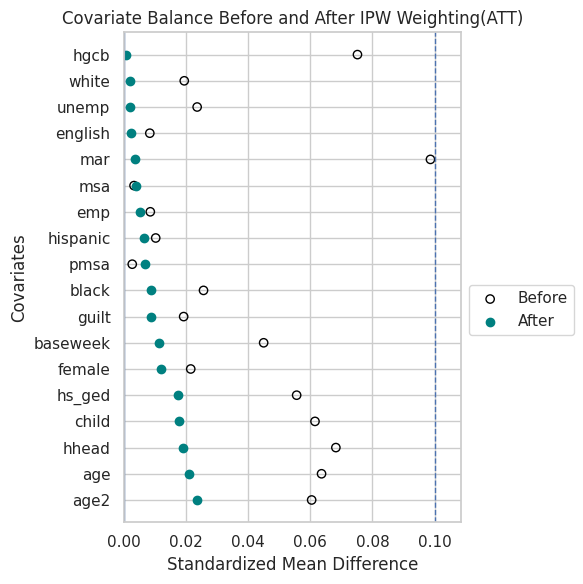

In [23]:
smd_love_plot(
    df_weighted,
    covariates,
    treat_col=treat_col,
    weight_col='weight_att'
)

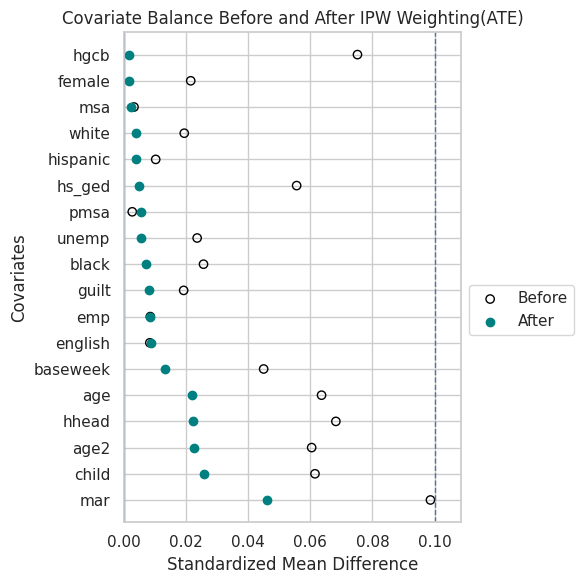

In [24]:
smd_love_plot(
    df_weighted,
    covariates,
    treat_col=treat_col,
    weight_col='weight_ate'
)

Both love plots show that covariate imbalance between treated and control groups is substantially reduced after adjustment. Before adjustment, several variables exhibited moderate imbalance (SMD up to ~0.10), but after adjustment, all covariates fall well below the conventional threshold of 0.10, with most below 0.05. This indicates that the reweighting/matching procedure successfully balanced the observed covariates, improving comparability between groups and supporting the validity of the estimated treatment effect.

*4-3. Estimate treatment effect with IPW (Inverse Probability Weighting) regression model*

IPW-weighted regression is used instead of a simple weighted mean comparison to provide a more stable and flexible framework for treatment effect estimation. Combining IPW with regression adjustment can improve estimation efficiency and allows additional covariate adjustment after weighting, particularly in finite samples where pure IPW estimators may be sensitive to extreme weights.

In [25]:
import statsmodels.api as sm

def ipw_te (df, treat_col, outcome_col, weight_col):

    X = sm.add_constant(df[[treat_col] + covariates])
    Y = df[outcome_col]
    W = df[weight_col]    # ipw weights

    ipw_model = sm.WLS(Y, X, W)
    ipw_result = ipw_model.fit(cov_type='HC1')

    estimate = ipw_result.params[treat_col]
    se = ipw_result.bse[treat_col]
    tstat = ipw_result.tvalues[treat_col]
    pval = ipw_result.pvalues[treat_col]

    ipw_summary = pd.Series({
        'method': "IPW",
        'effect': "ATT" if weight_col == 'weight_att'
                  else "ATE" if weight_col == 'weight_ate'
                  else "NA",
        'estimate': round(estimate, 4),
        'se': round(se, 4),
        't-stat': round(tstat, 4),
        'p-value': round(pval, 4) if pval > 0.0001 else "<0.0001"
    })

    return ipw_summary

In [26]:
ipw_att_summary = ipw_te(
    df_weighted,
    treat_col,
    outcome_col,
    weight_col='weight_att'
)

print(ipw_att_summary)

method          IPW
effect          ATT
estimate    14.8785
se           4.1798
t-stat       3.5596
p-value      0.0004
dtype: object


In [27]:
ipw_ate_summary = ipw_te(
    df_weighted,
    treat_col,
    outcome_col,
    weight_col='weight_ate'
)

print(ipw_ate_summary)

method         IPW
effect         ATE
estimate    15.923
se          4.1749
t-stat       3.814
p-value     0.0001
dtype: object


**5. Treatment Effect Estimation Using Nearest Neighbors Matching**

Nearest neighbors matching is used to construct a more comparable control group by pairing treated individuals with observationally similar control individuals based on estimated propensity scores. This approach helps reduce observable selection bias and provides an intuitive framework for estimating treatment effects through matched treated-control comparisons.

In [28]:
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import numpy as np

def nnmatch_att(df, treat_col, outcome_col, pscore_col):

    df = df.copy().reset_index(drop=True)

    treated = df[df[treat_col] == 1].reset_index(drop=True)
    control = df[df[treat_col] == 0].reset_index(drop=True)

    T = df[treat_col].values
    Y = df[outcome_col].values

    # match each treated unit to nearest control(s)
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[[pscore_col]])
    distances, indices = nn.kneighbors(treated[[pscore_col]])

    # ATT: mean outcome difference between treated and their matched controls
    matched_control_outcomes = np.array([
        control.loc[idx, outcome_col].mean() for idx in indices
    ])

    att = (treated[outcome_col].values - matched_control_outcomes).mean()

    # Abadie-Imbens SE:
    n = len(df)
    n_treated = len(treated)

    # count how many times each control unit was used as a match
    matched_control_indices = indices.flatten()
    match_counts = np.zeros(len(control))
    for idx in matched_control_indices:
        match_counts[idx] += 1

    # build K_i for all units: 0 for treated, match count for controls
    K = np.zeros(n)
    control_positions = df[df[treat_col] == 0].index
    for i, pos in enumerate(control_positions):
        K[pos] = match_counts[i]

    # conditional variance estimation: var(Y(1)|X) and var(Y(0)|X)
    # estimated locally using nearest neighbors in outcome space
    nn_var = NearestNeighbors(n_neighbors=4)
    nn_var.fit(df[[pscore_col]])
    _, var_indices = nn_var.kneighbors(df[[pscore_col]])

    sigma2 = np.array([
        np.var(Y[var_indices[i]], ddof=1) for i in range(n)
    ])

    # Abadie-Imbens variance formula
    ai_variance = np.sum((1 + K) ** 2 * sigma2) / (n_treated ** 2)
    se = np.sqrt(ai_variance)

    tstat = att / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), n_treated - 1))

    nnmatch_att_summary = pd.Series({
        'method': "nearest neighbors",
        'effect': "ATT",
        'estimate': round(att, 4),
        'se': round(se, 4),
        't-stat': round(tstat, 4),
        'p-value': round(pval, 4) if pval > 0.0001 else "<0.0001"
    })

    return nnmatch_att_summary

In [29]:
nnmatch_att_summary = nnmatch_att(
    df_trimmed,
    treat_col,
    outcome_col,
    pscore_col
)

print(nnmatch_att_summary)

method      nearest neighbors
effect                    ATT
estimate              20.9105
se                     7.6229
t-stat                 2.7431
p-value                0.0061
dtype: object


**6. Treatment Effect Estimation Using Augmented Inverse Probability Weighting (AIPW)**

AIPW is used to improve robustness relative to standard IPW methods by combining inverse probability weighting with outcome regression adjustment. Unlike standard IPW estimators, AIPW is doubly robust, meaning the treatment effect estimator remains consistent if either the propensity score model or the outcome model is correctly specified.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor

def aipw_ate(
    df,
    covariates,
    treat_col,
    outcome_col,
    pscore_col,
    n_splits=5,
    random_state=42
):

    X = df[covariates].values
    T = df[treat_col].values
    Y = df[outcome_col].values
    ps = df[pscore_col].values

    mu1 = np.zeros(len(df))
    mu0 = np.zeros(len(df))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        T_train = T[train_idx]
        Y_train = Y[train_idx]

        # fit outcome models on training fold only
        mu1_model = GradientBoostingRegressor(random_state=random_state)
        mu0_model = GradientBoostingRegressor(random_state=random_state)

        mu1_model.fit(X_train[T_train == 1], Y_train[T_train == 1])
        mu0_model.fit(X_train[T_train == 0], Y_train[T_train == 0])

        # predict on test fold (out-of-sample)
        mu1[test_idx] = mu1_model.predict(X_test)
        mu0[test_idx] = mu0_model.predict(X_test)

    aipw = (
        mu1 - mu0
        + T * (Y - mu1) / ps
        - (1 - T) * (Y - mu0) / (1 - ps)
    )

    ate = np.mean(aipw)
    se = np.std(aipw) / np.sqrt(len(aipw))
    tstat = ate / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), len(aipw) - 1))

    aipw_ate_summary = pd.Series({
        "method": "AIPW",
        "effect": "ATE",
        "estimate": round(ate, 4),
        "se": round(se, 4),
        "t-stat": round(tstat, 4),
        "p-value": round(pval, 4) if pval > 0.0001 else "<0.0001"
    })

    return aipw_ate_summary

In [31]:
aipw_ate_summary = aipw_ate(
    df_trimmed,
    covariates,
    treat_col,
    outcome_col,
    pscore_col
)

print(aipw_ate_summary)

method         AIPW
effect          ATE
estimate    16.0018
se           4.4761
t-stat       3.5749
p-value      0.0004
dtype: object


**7. Treatment Effect Estimation Using Double Machine Learning (DML)**

DML is used to estimate treatment effects in a flexible high-dimensional setting while reducing bias from model misspecification. By combining machine learning methods with orthogonalization and cross-fitting, DML improves robustness to overfitting and supports more reliable estimation and inference compared with traditional parametric causal inference methods.

In [32]:
pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


In [33]:
from econml.dml import DML
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold

def dml_ate(df, covariates, treat_col, outcome_col):

    X = df[covariates].values
    T = df[treat_col].values
    Y = df[outcome_col].values

    dml_model = DML(
        model_y=GradientBoostingRegressor(),
        model_t=GradientBoostingClassifier(),
        model_final=StatsModelsLinearRegression(fit_intercept=False),
        discrete_treatment=True,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42
    )

    dml_model.fit(Y, T, X=X, W=None)

    ate = dml_model.ate(X)
    ate_lb, ate_ub = dml_model.ate_interval(X)
    se = (ate_ub - ate_lb) / (2 * 1.96)
    tstat = ate / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), len(Y) - 1))

    dml_ate_summary = pd.Series({
        "method": "DML",
        "effect": "ATE",
        "estimate": round(ate, 4),
        "se": round(se, 4),
        "t-stat": round(tstat, 4),
        "p-value": round(pval, 4) if pval > 0.0001 else "<0.0001"
    })

    return dml_ate_summary

In [34]:
dml_ate_summary = dml_ate(
    df_trimmed,
    covariates,
    treat_col,
    outcome_col
)

print(dml_ate_summary)

method         DML
effect         ATE
estimate    14.125
se          3.9645
t-stat      3.5629
p-value     0.0004
dtype: object


**8. Treatment Effect Estimation Using Causal Forests**

Causal forests are used to estimate heterogeneous treatment effects by flexibly modeling how treatment impacts vary across individuals with different characteristics. Unlike traditional average treatment effect methods, causal forests can capture complex nonlinear relationships and interaction effects in high-dimensional data, making them particularly useful for identifying variation in program effectiveness across subpopulations.

In [35]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingClassifier

def causal_forest_ate(df, covariates, treat_col, outcome_col):
    cf_model = CausalForestDML(
        model_t=GradientBoostingClassifier(),
        model_y=GradientBoostingRegressor(),
        discrete_treatment=True,
        n_estimators=1000,
        min_samples_leaf=100,
        max_depth=None,
        random_state=42,
        cv = 3
    )

    df = df.copy()

    T = df[treat_col].values.astype(int)
    Y = df[outcome_col].values
    X = df[covariates].values

    cf_model.fit(Y=Y, T=T, X=X, cache_values=True)

    # ATE
    ate_inf = cf_model.ate_inference(X)
    ate = ate_inf.mean_point
    se = ate_inf.stderr_mean
    tstat = ate / se
    pval = 2 * (1 - stats.norm.cdf(abs(tstat)))

    # CATE
    df["estimated_cate"] = cf_model.effect(X)

    cf_ate_summary = pd.Series({
        'method': "causal forest",
        'effect': "ATE",
        'estimate': round(ate, 4),
        'se': round(se, 4),
        't-stat': round(tstat, 4),
        'p-value': round(pval, 4) if pval > 0.0001 else "<0.0001"
    })

    return df, cf_ate_summary

In [36]:
df_cate, cf_ate_summary= causal_forest_ate(
    df_trimmed,
    covariates,
    treat_col,
    outcome_col
)

In [37]:
print(cf_ate_summary)

method      causal forest
effect                ATE
estimate          15.9551
se                 8.0466
t-stat             1.9828
p-value            0.0474
dtype: object


**9. Summary of Treatment Effect Estimates Across Methods**



In [38]:
te_df = pd.DataFrame([
    did_att_summary,
    ipw_att_summary,
    ipw_ate_summary,
    nnmatch_att_summary,
    aipw_ate_summary,
    dml_ate_summary,
    cf_ate_summary
])

In [39]:
print(te_df.round(4))

              method effect  estimate      se  t-stat  p-value
0                DID    ATT   15.6169  4.2938  3.6370   0.0003
1                IPW    ATT   14.8785  4.1798  3.5596   0.0004
2                IPW    ATE   15.9230  4.1749  3.8140   0.0001
3  nearest neighbors    ATT   20.9105  7.6229  2.7431   0.0061
4               AIPW    ATE   16.0018  4.4761  3.5749   0.0004
5                DML    ATE   14.1250  3.9645  3.5629   0.0004
6      causal forest    ATE   15.9551  8.0466  1.9828   0.0474


### Convergence and method agreement
Four of the five estimators converge tightly in the 14–16 range, which
strengthens confidence in the result. DID (15.62), IPW (14.87, 15.92), AIPW
(16.00), and Causal Forest (15.93) all tell a consistent story: Job Corps
participation increased weekly earnings by approximately $14–16 for the
relevant target population. This convergence is meaningful precisely because
these methods rest on different identifying assumptions — IPW weights on the
propensity score, AIPW adds doubly robust outcome modeling, and Causal
Forest uses a fully nonparametric residual-on-residual approach. Agreement
across them suggests the result is not an artifact of any single modeling
choice.

The NNM estimate of 20.91 is the notable outlier. Nearest-neighbor matching
on the propensity score is sensitive to the quality of matches in sparse
regions of the covariate space, and a small number of treated units with
poor matches can pull the ATT estimate upward meaningfully. The wider SE
(7.62 vs ~4.48 for IPW/AIPW) reflects this added uncertainty.

###ATT vs ATE: more than a technical distinction
The estimators here target two different quantities, and the difference
matters economically for a program like Job Corps.

**ATT** (DID, NNM) measures the average effect on those who actually
enrolled. Job Corps is a voluntary program, and participation is selective —
enrollees tend to be younger, lower-income, and further from the labor
market than the average eligible person. If individuals with the most to
gain are also the most likely to enroll (positive selection on gains), then
ATT > ATE: the program works especially well for the people who chose it,
but would deliver smaller returns if extended to a broader population.

**ATE** (IPW, AIPW, Causal Forest) measures the average effect across all
eligible individuals, including those who did not enroll. If non-enrollees
face fewer barriers or have stronger baseline labor market attachment, the
program might move them less — pulling ATE below ATT.

In practice, the estimates here do not show a dramatic ATT–ATE gap: DID
(ATT, 15.62) and IPW (ATE, 15.92) are close, and AIPW (ATE, 16.00) sits
slightly above both. This near-convergence suggests that, within this
sample, selection on gains is modest — the program appears to deliver
similar returns regardless of whether we condition on actual participation
or average across all eligible individuals. That is itself a substantively
interesting finding: it weakens the case that Job Corps works only because
it attracts a particularly responsive subgroup.

### Causal Forest SE

The wider SE from Causal Forest (8.01 vs ~4.48, except NNM) is expected rather than concerning. The forest estimator is nonparametric and does not impose
functional form restrictions on treatment effect heterogeneity, so it trades
some precision for flexibility. The fact that its point estimate (15.93)
aligns closely with the parametric ATE estimates validates the overall
finding while the wider interval honestly reflects the cost of that
flexibility.

### Bottom line

Job Corps participation increased weekly earnings by approximately $14–16,
an effect that is statistically robust across all five estimators and
methodologically robust across both ATT and ATE targets. The near-equality
of ATT and ATE estimates suggests limited selection on treatment effect
gains within this sample, implying the program's benefits are not
concentrated solely among those who self-selected into it.


**9. Policy allocation analysis using CATE (Conditional Average Treatment Effect)**

Treatment effects may vary substantially across individuals, making average treatment effects insufficient for policy decision-making. This section uses estimated Conditional Average Treatment Effects (CATE) to examine how treatment prioritization can improve expected program impact under limited resources.

In [40]:
def policy_allocation_analysis(
    df,
    cate_col,
    outcome_col,
    treat_col,
    cost_levels=None,
    selected_percents=np.arange(0.05, 1.05, 0.05)
):

    if cost_levels is None:
        cost_levels = [5, 10, 15, 20]

    df = df.copy()
    df = df.sort_values(cate_col, ascending=False).reset_index(drop=True)

    policy_summary = []

    for cost in cost_levels:
        for pct in selected_percents:

            n_selected = int(len(df) * pct)
            selected_group = df.iloc[:n_selected]
            expected_benefit = selected_group[cate_col].sum()
            total_cost = n_selected * cost
            net_benefit = expected_benefit - total_cost
            benefit_cost_ratio = (
                net_benefit / total_cost
                if total_cost > 0 else np.nan
            )

            policy_summary.append({
                "cost"             : cost,
                "selected_pct"     : f"{pct:.2f}",
                "n_selected"       : n_selected,
                "expected_benefit" : round(expected_benefit, 2),
                "total_cost"       : round(total_cost, 2),
                "net_benefit"      : round(net_benefit, 2),
                "benefit_cost_ratio": (round(benefit_cost_ratio, 2)
                    if not np.isnan(benefit_cost_ratio) else np.nan)
            })

    policy_summary = pd.DataFrame(policy_summary)

    policy_plot, ax = plt.subplots(figsize=(6, 4))

    for cost in cost_levels:
        subset = policy_summary[policy_summary["cost"] == cost]
        ax.plot(
            subset["selected_pct"],
            subset["net_benefit"],
            marker="o", markersize=4, label=f"cost=${cost}"
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Selected Population Share")
    ax.set_ylabel("Expected Net Benefit")
    ax.set_title("Expected Program Benefit by Treatment Prioritization")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.show()

    return policy_summary, policy_plot

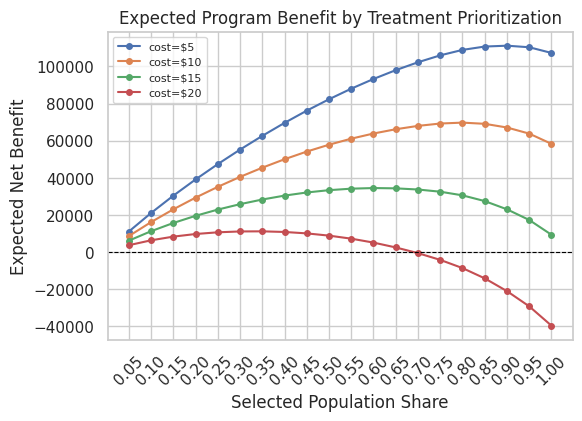

In [41]:
policy_summary, policy_plot = policy_allocation_analysis(
    df_cate,
    cate_col='estimated_cate',
    outcome_col=outcome_col,
    treat_col=treat_col,
    cost_levels=[5, 10, 15, 20]
)

Net benefit peaks well before full population coverage for all cost levels,
confirming that indiscriminate treatment is suboptimal. At cost=\$5, the
program remains net-positive across the entire population share range,
peaking around 90% selection. At cost=$10, net benefit peaks near
70–80% before declining but stays positive throughout. At cost=\$15, the
curve flattens earlier and turns negative only at full coverage. At cost=\$20,
the break-even point is crossed around 70% selection, turning sharply
negative thereafter.